# 3. Which segment

**Week 1, Tuesday. Chapter 3 of 6.** By the end of this notebook you can write two functions that return the tree and the shape of any group of orders, run them on any segment and quarter, and roll a rate up to the company figure without averaging the averages.

> **The client asks.** "One of my members says the app's reorder button has been broken for six
> weeks. Is my tier the one slipping?"
>
> The head of Retail-Plus, Kalpa's paid membership tier

**What chapter 2 established, and what this adds.** Customers held at 69, orders per customer fell
from 1.65 to 1.25 and took Rs 51,57,895 with it, revenue per order rose 18.0 percent, and the discount
branch is worth at most Rs 12,900. Chapter 2's loop counted customers and orders for one group at a
time. This chapter needs the same numbers for four segments in two quarters, eight groups, and the
loop becomes a function: one tool, written once, called for any group.

> **Kavya's review of chapter 2.** "You have written the same accumulating loop three times since
> this morning. The fourth time, write it once, give it a name, and make it hand back its answer."

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
groups = {"Q1": {}, "Q2": {}}       # quarter -> segment -> list of orders
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    q, seg = order["quarter"], order["segment"]
    groups[q].setdefault(seg, []).append(order)
    by_quarter[q].append(order)
print(len(SEGMENTS), "segments,", len(ORDERS), "orders grouped by quarter and segment")

4 segments, 200 orders grouped by quarter and segment


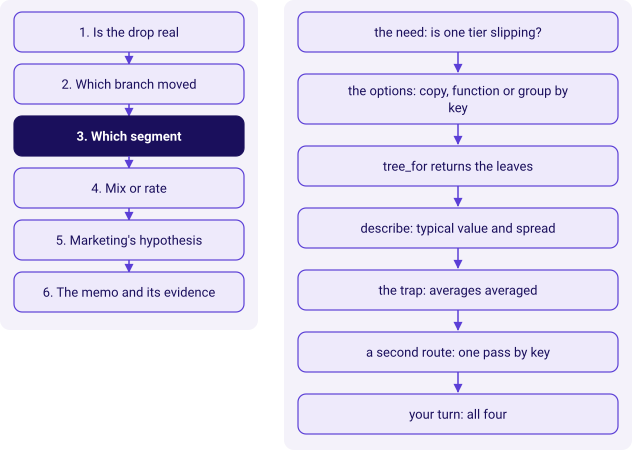

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real', 'Which branch moved', 'Which segment', 'Mix or rate', "Marketing's hypothesis", 'The memo and its evidence'], lit=2, show=False),
    kit.vflow(['the need: is one tier slipping?', 'the options: copy, function or group by key', 'tree_for returns the leaves', 'describe: typical value and spread', 'the trap: averages averaged', 'a second route: one pass by key', 'your turn: all four'], show=False),
)

## The need

Kalpa sells to four kinds of customer. Retail-Core buys a few thousand rupees at a time; Retail-Plus
pays a membership fee for benefits and is meant to order more often; Business buys in bulk, lakhs per
order; Student is a small discounted segment. The head of Retail-Plus owns the paid tier's renewals,
so his question is the metric of his job: orders per member, this quarter against last. The decision
riding on it is whether his team gets the problem, and the fund to fix it, or whether it sits
elsewhere. A wrong number costs either a tier nobody protects, or a quarter spent fixing a tier that
was fine.

**Who else faces this.** Costco reports its membership renewal rate twice: for the United States
and Canada, and worldwide. At the end of its fiscal 2025 the first stood at 92.3 percent and the second
at 89.8 percent (Costco, fourth quarter fiscal 2025 results filed with the SEC, checked 30 Sep 2026).
One blended rate would hide where renewals are weaker, so the segments are reported beside the whole,
which is what the head of Retail-Plus needs from us.

## The options

The same five numbers, revenue, orders, customers, orders per customer and revenue per order, are
needed for eight groups. Three ways a team could produce them.

| Option | How | The cost that matters |
|---|---|---|
| A. Copy the loop per group | Paste chapter 2's loop eight times, one per segment and quarter | Eight places to edit when the definition changes, and eight chances to edit seven |
| B. Write a function | `tree_for(rows)` takes any list of orders and returns the five numbers | One place to edit; each call reads its own group |
| C. Group by a key in one pass | One loop over all 200 orders adds into `totals[(quarter, segment)]` | One pass over the rows; the code is shaped for these eight groups only |

The cell below sizes each: lines of code, places to edit when Anand changes the definition to
delivered orders, and rows read.

Option,Lines of code,Places to edit for a new definition,Rows read,Reuse later today
A. copy per group,72,8,1600,paste again for channel and month
B. a function,21,1,200,"any list: a channel, a month, delivered only"
C. group by key,14,1,200,these eight groups; a new key means a new loop


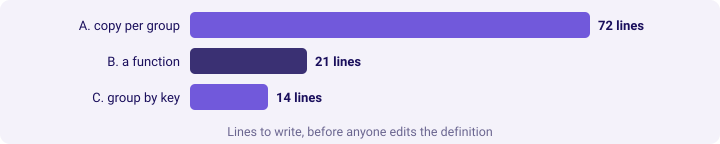

In [3]:
def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers,
            "revenue_per_order": revenue / orders}


def describe(amounts):
    """A group's typical value and spread: median, min, max and range (chapter 3)."""
    ordered = sorted(amounts)
    n = len(ordered)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2
    return {"median": median, "min": ordered[0], "max": ordered[-1], "range": ordered[-1] - ordered[0]}

import time
copy_lines = 8 * 9                                # the chapter 2 loop is nine lines, pasted eight times
function_lines = 13 + 8                           # tree_for once, then one call per group
key_lines = 14
reads = {"A": 0, "B": 0, "C": 0}
t0 = time.perf_counter()
for q in ("Q1", "Q2"):
    for seg in SEGMENTS:
        reads["A"] += len(ORDERS)                 # each pasted loop filters the whole export
        tree_for(groups[q][seg]); reads["B"] += len(groups[q][seg])
secs_b = time.perf_counter() - t0
reads["C"] = len(ORDERS)
kit.table(["Option", "Lines of code", "Places to edit for a new definition", "Rows read", "Reuse later today"],
          [("A. copy per group", copy_lines, 8, reads["A"], "paste again for channel and month"),
           ("B. a function", function_lines, 1, reads["B"], "any list: a channel, a month, delivered only"),
           ("C. group by key", key_lines, 1, reads["C"], "these eight groups; a new key means a new loop")],
          caption=f"Sizing three ways to get eight trees; the eight function calls ran in {secs_b * 1000:.2f} ms")
kit.bars([("A. copy per group", copy_lines), ("B. a function", function_lines), ("C. group by key", key_lines)],
         fmt=lambda v: f"{v} lines", lit=[1], title="Lines to write, before anyone edits the definition")
kit.check("a function reads each order once across the eight groups", reads["B"] == len(ORDERS), f'{reads["B"]}')
kit.check("copying reads the export eight times over", reads["A"] == 8 * len(ORDERS), f'{reads["A"]}')

**The best-fit call.** Option B, a function, because the same five numbers will be asked for a
channel, a month and delivered orders before the day ends, and a function answers every one of them
with one line; on 200 rows the speed of each option is a matter of milliseconds and decides nothing.
**The fact that would change the call:** if the export grew to millions of rows and every group were
needed at once, option C, one pass by key, would win on rows read, which is what `groupby` in pandas
does in Week 2.

## 1. A function returns the tree for any list of orders

`tree_for(rows)` returns rather than prints, so the caller can put the answer in a table, a chart or
a check.

**Predict before you run.** What will `tree_for(by_quarter["Q1"])["orders_per_customer"]` give,
rounded? a) 1.65; b) 1.25; c) `None`; d) 1.94.

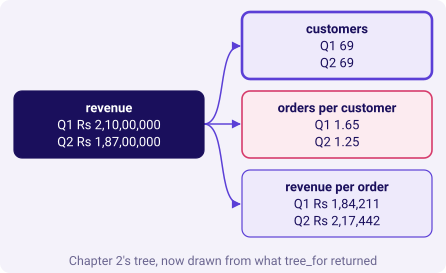

In [4]:
q1 = tree_for(by_quarter["Q1"])
q2 = tree_for(by_quarter["Q2"])
kit.driver_tree({"label": "revenue", "note": f'Q1 {kit.rupees(q1["revenue"])}\nQ2 {kit.rupees(q2["revenue"])}', "kind": "lit", "children": [
    {"label": "customers", "note": f'Q1 {q1["customers"]}\nQ2 {q2["customers"]}', "kind": "known"},
    {"label": "orders per customer", "note": f'Q1 {q1["orders_per_customer"]:.2f}\nQ2 {q2["orders_per_customer"]:.2f}', "kind": "bad"},
    {"label": "revenue per order", "note": f'Q1 {kit.rupees(round(q1["revenue_per_order"]))}\nQ2 {kit.rupees(round(q2["revenue_per_order"]))}'}]},
    title="Chapter 2's tree, now drawn from what tree_for returned", width_per=190)
kit.check("tree_for reproduces chapter 2's orders per customer",
          (round(q1["orders_per_customer"], 2), round(q2["orders_per_customer"], 2)) == (1.65, 1.25))
kit.check("tree_for returns all five leaves", len(q1) == 5 and "revenue_per_order" in q1, ", ".join(q1))

**What happened.** The answer is a. The function reproduces chapter 2: 1.65 in Q1 and 1.25 in Q2, on
69 customers each. Option c is what a function hands back when it prints its answer and returns
nothing; chapter 5 meets a colleague's function that does exactly that.

## 2. Retail-Core: frequency slipped a little, and the typical order fell

A segment gets a typical value and a spread, and `describe(amounts)` returns both: the median, the
smallest and largest order, and the range between them.

**Predict before you run.** Retail-Core's orders per customer, Q1 against Q2: a) it fell by about a
quarter, like the company; b) it rose; c) it fell by about 5 percent; d) it did not move.

Retail-Core,Orders,Customers,Orders per customer,Median,Min,Max,Range
Q1,38,34,1.12,"Rs 2,325",Rs 860,"Rs 3,000","Rs 2,140"
Q2,36,34,1.06,"Rs 2,080",Rs 890,"Rs 2,950","Rs 2,060"


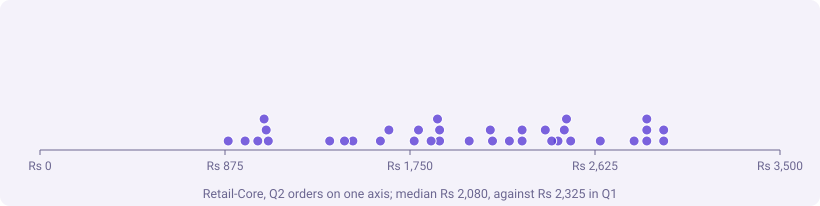

In [5]:
core = {q: tree_for(groups[q]["Retail-Core"]) for q in ("Q1", "Q2")}
core_amounts = {q: [o["amount"] for o in groups[q]["Retail-Core"]] for q in ("Q1", "Q2")}
core_shape = {q: describe(core_amounts[q]) for q in core_amounts}
core_change = (core["Q2"]["orders_per_customer"] / core["Q1"]["orders_per_customer"] - 1) * 100
kit.table(["Retail-Core", "Orders", "Customers", "Orders per customer", "Median", "Min", "Max", "Range"],
          [(q, core[q]["orders"], core[q]["customers"], f'{core[q]["orders_per_customer"]:.2f}',
            kit.rupees(round(core_shape[q]["median"])), kit.rupees(core_shape[q]["min"]),
            kit.rupees(core_shape[q]["max"]), kit.rupees(core_shape[q]["range"])) for q in ("Q1", "Q2")],
          caption=f"Retail-Core orders per customer moved {core_change:.1f} percent")
kit.strip(core_amounts["Q2"], lo=0, hi=3500,
          title=f'Retail-Core, Q2 orders on one axis; median {kit.rupees(core_shape["Q2"]["median"])}, against {kit.rupees(core_shape["Q1"]["median"])} in Q1')
kit.check("Retail-Core customers held at 34", core["Q1"]["customers"] == core["Q2"]["customers"] == 34)
kit.check("Retail-Core orders per customer fell 5.3 percent", round(core_change, 1) == -5.3, f"{core_change:.2f}")

**What happened.** The answer is c. The same 34 Retail-Core customers placed 36 orders against 38, so
orders per customer moved from 1.12 to 1.06, down 5.3 percent, and the typical order fell from
Rs 2,325 to Rs 2,080. Retail-Core slipped a little, far short of the company's 24.6 percent.

## 3. Business: the median barely moves while the range grows by nearly three quarters

**Predict before you run.** Business revenue fell from Rs 2,07,71,180 to Rs 1,85,41,460. What does
`describe` show about the typical Business order? a) the median fell by about a tenth, like revenue;
b) the median barely moved and the largest order grew a lot; c) every order got smaller; d) the
median rose sharply.

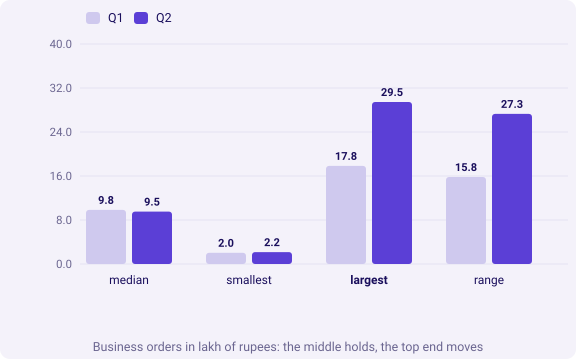

In [6]:
biz = {q: tree_for(groups[q]["Business"]) for q in ("Q1", "Q2")}
biz_amounts = {q: [o["amount"] for o in groups[q]["Business"]] for q in ("Q1", "Q2")}
biz_shape = {q: describe(biz_amounts[q]) for q in biz_amounts}
biz_change = (biz["Q2"]["orders_per_customer"] / biz["Q1"]["orders_per_customer"] - 1) * 100
kit.columns(["median", "smallest", "largest", "range"],
            [(q, [biz_shape[q]["median"], biz_shape[q]["min"], biz_shape[q]["max"], biz_shape[q]["range"]]) for q in ("Q1", "Q2")],
            fmt=lambda v: f"{v / 1e5:.1f}", lit=[2],
            title="Business orders in lakh of rupees: the middle holds, the top end moves")
kit.check("Business customers held at 11", biz["Q1"]["customers"] == biz["Q2"]["customers"] == 11)
kit.check("Business orders per customer fell 15.0 percent", round(biz_change, 1) == -15.0, f"{biz_change:.2f}")
kit.check("the Business range grew more than 70 percent while the median moved under 4 percent",
          biz_shape["Q2"]["range"] / biz_shape["Q1"]["range"] > 1.7
          and abs(biz_shape["Q2"]["median"] / biz_shape["Q1"]["median"] - 1) < 0.04)

**What happened.** The answer is b. The median Business order moved from Rs 9,83,780 to Rs 9,52,000,
while the largest grew from Rs 17,84,000 to Rs 29,45,460 and the range rose about 73 percent. One large
order sets the range. The eleven Business customers placed 17 orders against 20, down 15.0 percent
per customer, on three orders. Neither segment shown falls 24.6 percent, so before guessing where the
rest sits, roll the segments back up.

## 4. The trap: rolling the segments up by averaging their averages

With `tree_for` in hand, the company figure looks one line away: run it on all four segments and
average their orders per customer.

**Predict before you run.** Averaged over the four segments, how far does orders per customer fall?
a) 24.6 percent, the same as chapter 2; b) much less than chapter 2; c) more than chapter 2; d) it
rises.

**The plausible wrong answer.** A hurried analyst averages the four segment rates in each quarter.

In [7]:
averaged = {}
for q in ("Q1", "Q2"):
    total = 0
    for seg in SEGMENTS:
        total += tree_for(groups[q][seg])["orders_per_customer"]
    averaged[q] = total / len(SEGMENTS)
averaged_change = (averaged["Q2"] / averaged["Q1"] - 1) * 100
kit.stats([(f'{averaged["Q1"]:.2f}', "Q1, average of 4 segments", "each segment counted once"),
           (f'{averaged["Q2"]:.2f}', "Q2, average of 4 segments", "each segment counted once"),
           (f"{averaged_change:.1f}%", "the hurried change", "so frequency is not the branch?")])

**Why it is wrong.** The answer to the prediction is b, and it is the wrong conclusion. Averaging
the averages gives every segment one vote, so a segment of 2 customers counts as much as one of 34.
"Frequency fell only 6.0 percent, so it is not the branch, and Marketing may be right" would send
Meera back to the acquisition budget on a number that describes no customer. **The check:** a roll-up
of the segments must reproduce the company figure, 1.65 and 1.25, and this one does not.

The mechanism on **invented** numbers: 30 customers who order 1.1 times each, and 2 who order 3.5
times each.

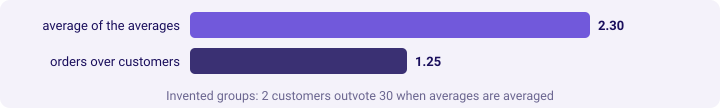

In [8]:
small_group = {"customers": 2, "orders_per_customer": 3.5}     # invented, not Kalpa's
large_group = {"customers": 30, "orders_per_customer": 1.1}    # invented, not Kalpa's
avg_of_avgs = (small_group["orders_per_customer"] + large_group["orders_per_customer"]) / 2
orders_all = sum(g["customers"] * g["orders_per_customer"] for g in (small_group, large_group))
weighted_inv = orders_all / (small_group["customers"] + large_group["customers"])
kit.bars([("average of the averages", round(avg_of_avgs, 2)), ("orders over customers", round(weighted_inv, 2))],
         fmt=lambda v: f"{v:.2f}", lit=[1], title="Invented groups: 2 customers outvote 30 when averages are averaged")
kit.check("the averaged roll-up misses chapter 2's Q1 figure", round(averaged["Q1"], 2) != round(q1["orders_per_customer"], 2),
          f'{averaged["Q1"]:.2f} against {q1["orders_per_customer"]:.2f}')
kit.check("the hurried change is minus 6.0 percent", round(averaged_change, 1) == -6.0, f"{averaged_change:.2f}")

**The fix.** Weight by customers: add the orders across segments and divide by the customers across
segments. Count the groups in and out as you do it: four segments go in, and their customers must add
back to 69.

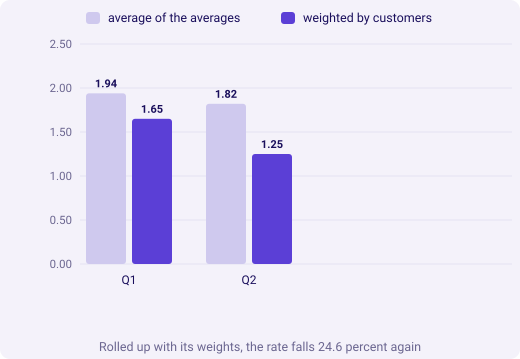

In [9]:
weighted, groups_used, customers_used = {}, {}, {}
for q in ("Q1", "Q2"):
    all_orders = all_customers = 0
    groups_used[q] = 0
    for seg in SEGMENTS:
        t = tree_for(groups[q][seg])
        all_orders += t["orders"]
        all_customers += t["customers"]
        groups_used[q] += 1
    weighted[q] = all_orders / all_customers
    customers_used[q] = all_customers
weighted_change = (weighted["Q2"] / weighted["Q1"] - 1) * 100
kit.columns(["Q1", "Q2"], [("average of the averages", [round(averaged["Q1"], 2), round(averaged["Q2"], 2)]),
                           ("weighted by customers", [round(weighted["Q1"], 2), round(weighted["Q2"], 2)])],
            fmt=lambda v: f"{v:.2f}", width=520, title="Rolled up with its weights, the rate falls 24.6 percent again")
kit.check("the weighted roll-up reproduces chapter 2", abs(weighted["Q1"] - q1["orders_per_customer"]) < 1e-12
          and abs(weighted["Q2"] - q2["orders_per_customer"]) < 1e-12)
kit.check("four groups in, four out, and their customers add back to 69",
          groups_used["Q1"] == groups_used["Q2"] == 4 and customers_used["Q1"] == customers_used["Q2"] == 69)

**What changed.** "Frequency fell 6.0 percent, so Marketing may be right" became "orders per customer
fell from 1.65 to 1.25, 24.6 percent, across the same count of 69 customers", which keeps frequency
as the branch and keeps the acquisition budget shut. Retail-Core and Business carry part of it, and
the weighted roll-up says the rest sits in the segments not yet opened.

## A second route: one pass, grouped by key

Option C, built as the check on option B. One loop over the 200 orders adds each order into
`totals[(quarter, segment)]`; if every one of the eight groups gives the same five numbers as
`tree_for`, the function is right. The comparison runs inside a check, so it prints agreement and no
segment's numbers.

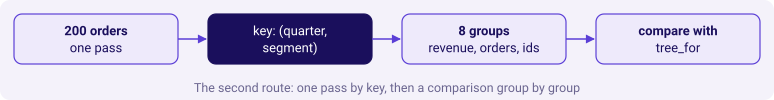

In [10]:
totals = {}
for order in ORDERS:
    key = (order["quarter"], order["segment"])
    t = totals.setdefault(key, {"revenue": 0, "orders": 0, "ids": set()})
    t["revenue"] += order["amount"]
    t["orders"] += 1
    t["ids"].add(order["customer_id"])

agree = 0
for (q, seg), t in totals.items():
    via_function = tree_for(groups[q][seg])
    if (t["revenue"], t["orders"], len(t["ids"])) == (via_function["revenue"], via_function["orders"], via_function["customers"]):
        agree += 1
kit.flow(["200 orders\none pass", "key: (quarter, segment)", "8 groups\nrevenue, orders, ids", "compare with\ntree_for"],
         lit=1, title="The second route: one pass by key, then a comparison group by group")
kit.check("both routes give the same numbers for all eight groups", agree == len(totals) == 8, f"{agree} of {len(totals)}")

**When to switch.** Keep the function while groups are asked for one at a time; switch to the pass
by key when every group is needed at once on a large file, which is Week 2's `groupby`.

**Your turn.** Run the tree for all four segments in both quarters. Type these lines into the empty
cell below and run them:

```python
rows, opc_q1, opc_q2 = [], [], []
for seg in SEGMENTS:
    t1, t2 = tree_for(groups["Q1"][seg]), tree_for(groups["Q2"][seg])
    rows.append((seg, t1["customers"], t2["customers"], t1["orders"], t2["orders"],
                 f'{t1["orders_per_customer"]:.2f}', f'{t2["orders_per_customer"]:.2f}'))
    opc_q1.append(round(t1["orders_per_customer"], 2))
    opc_q2.append(round(t2["orders_per_customer"], 2))
kit.table(["Segment", "Customers Q1", "Customers Q2", "Orders Q1", "Orders Q2", "Per customer Q1", "Per customer Q2"], rows)
kit.columns(SEGMENTS, [("Q1", opc_q1), ("Q2", opc_q2)], fmt=lambda v: f"{v:.2f}", title="Orders per customer by segment")
```

Then write one sentence for the head of Retail-Plus that answers his question with a number and its
denominator.

> **Kavya's review.** "Two functions, eight groups, no copied loops. Retail-Core slipped 5.3 percent
> and Business 15.0, and neither is 24.6. The segment that carries the rest is on your screen now,
> in your own cell. Say it with its denominator before anyone draws a conclusion from it."

### In the interview

**[F] You have orders per customer for four segments; why can't you average them for the company
figure?** "Because each segment's rate has its own denominator, and averaging the rates gives every
segment the same weight whatever its size. The company figure is total orders over total customers,
which is the segment rates weighted by their customers. On Kalpa's quarters the unweighted average
said frequency fell 6.0 percent and the weighted figure says 24.6. The test I run on any roll-up is
that it reproduces the company total." The interviewer is listening for denominators, weights and
the reproduce-the-total test.

**The design question. The same metrics are needed for every segment and quarter; do you copy the
code, write a function or group by a key?** "A function, when the groups will be asked for one at a
time and the definition may change, since there is one place to edit and it answers any subset: a
channel, a month, delivered orders. Copying eight times means eight edits and one forgotten. I would
group by a key in one pass when the file is large and every group is needed at once; that is what
`groupby` does." The interviewer is listening for the cost that decides it: edits and reuse on a
small file, rows read on a large one.

### Depth: what a range can and cannot say

A range is set by two orders, the smallest and the largest, so one order can stretch it, as Business showed with a rise of about 73 percent; a median is set by the middle of the list, so it barely moves. Between the two, the middle
half of the sorted values says how wide the ordinary orders sit. Try it on Business: sort each
quarter's amounts, drop the lowest and highest quarter of the list, and take the range of what is
left. Thursday asks whether differences of this size are more than noise.

References for the chapter:

- Corey Schafer, "Python Tutorial for Beginners 8: Functions": https://www.youtube.com/watch?v=9Os0o3wzS_I (verified 29 Sep 2026)
- Python docs, "4. More Control Flow Tools", defining functions and return: https://docs.python.org/3/tutorial/controlflow.html (verified 29 Sep 2026)
- Khan Academy, mean, median and mode review: https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/mean-median-basics/a/mean-median-and-mode-review (verified 29 Sep 2026)

In [11]:
kit.check_summary()
print("Next: chapter 4, whether revenue per order rose because of mix or because of rate.")

Next: chapter 4, whether revenue per order rose because of mix or because of rate.
